In [1]:
import re
from pathlib import Path
import pandas as pd

input_path = Path("serial_20260309_180144.txt")
output_path = Path("serial_20260309_180144_clean.csv")

pattern = re.compile(
    r"(?P<ms>\d+),(?P<raw>-?\d+),(?P<v>-?\d+(?:\.\d+)?),(?P<currentA>-?\d+(?:\.\d+)?),(?P<lc_raw>-?\d+),(?P<lc_grams>NA|-?\d+(?:\.\d+)?)"
)

rows = []
with input_path.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            row = m.groupdict()
            row["ms"] = int(row["ms"])
            row["raw"] = int(row["raw"])
            row["v"] = float(row["v"])
            row["currentA"] = float(row["currentA"])
            row["lc_raw"] = int(row["lc_raw"])
            row["lc_grams"] = None if row["lc_grams"] == "NA" else float(row["lc_grams"])
            rows.append(row)

df = pd.DataFrame(rows, columns=["ms", "raw", "v", "currentA", "lc_raw", "lc_grams"])
df.to_csv(output_path, index=False)

print(f"Rows extracted: {len(df)}")
print(f"Saved cleaned CSV to: {output_path}")
print("\nPreview:")
print(df.head(10).to_string(index=False))


Rows extracted: 753
Saved cleaned CSV to: serial_20260309_180144_clean.csv

Preview:
   ms  raw     v  currentA  lc_raw  lc_grams
96899 1881 1.516     0.882 -350209      3.09
97093 1881 1.516     0.879 -350153      2.96
97383 1881 1.516     0.879 -350129      2.91
97576 1881 1.516     0.879 -350181      3.02
97766 1880 1.516     0.877 -350148      2.95
97991 1880 1.516     0.875 -350075      2.79
98219 1880 1.516     0.874 -350059      2.75
98413 1880 1.515     0.870 -350083      2.80
98661 1880 1.515     0.867 -350112      2.87
98787 1880 1.515     0.859 -350136       NaN


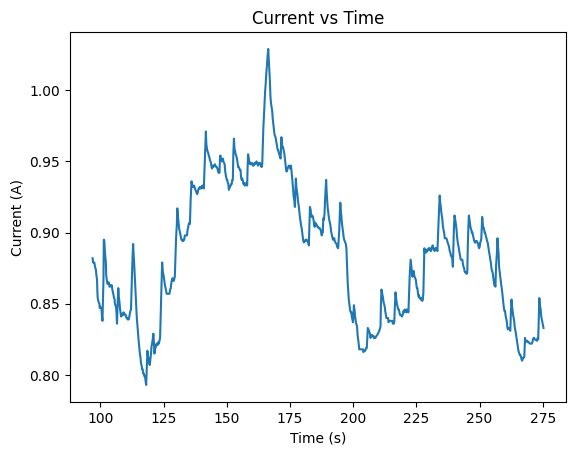

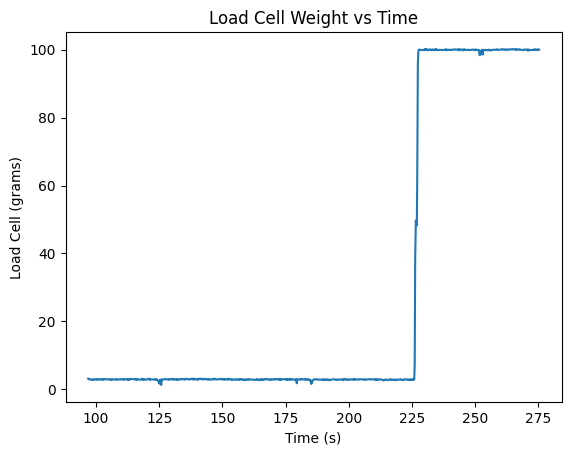

In [3]:
# Load the cleaned CSV and plot current and load cell grams against time
import pandas as pd
import matplotlib.pyplot as plt

path = "serial_20260309_180144_clean.csv"
df = pd.read_csv(path)

# Convert time to seconds for readability
df["time_s"] = df["ms"] / 1000.0

# Plot 1: Current vs Time
plt.figure()
plt.plot(df["time_s"], df["currentA"])
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("Current vs Time")
plt.show()

# Plot 2: Load Cell Grams vs Time
plt.figure()
plt.plot(df["time_s"], df["lc_grams"])
plt.xlabel("Time (s)")
plt.ylabel("Load Cell (grams)")
plt.title("Load Cell Weight vs Time")
plt.show()